# Module 4 — Random Forest (M4)
## Topic 10: Non-Linear Forecasting for Macroeconomic and Financial Data

**What this notebook covers**

| Step | Question | Tool |
|------|----------|------|
| 1 | What is a decision tree? | Single tree on GDP data |
| 2 | Why do single trees fail? | Variance vs bias, overfitting |
| 3 | How does bagging reduce variance? | Bootstrap aggregation |
| 4 | What is a Random Forest? | Bagging + random features |
| 5 | How do I build the feature matrix? | Lag engineering — same logic as AR/ARX |
| 6 | **The critical rule**: temporal discipline | No random splits, no look-ahead |
| 7 | How do I tune hyperparameters? | TimeSeriesSplit cross-validation |
| 8 | What does the RF learn? | Feature importance + partial dependence |
| 9 | Recursive OOS: RF vs AR vs ARX | RMSE/MAE, honest comparison |

**Datasets**
- 📊 **US quarterly macro 1959–2009** — GDP growth, investment, consumption, unemployment, inflation, T-bill (`statsmodels.macrodata`)
- 📈 **SP500 daily returns 1981–1991** — (`Ecdat/SP500`)

> In your own setup: replace with `fredapi` for macro, `yfinance` for equities — the RF code is identical.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.inspection import permutation_importance, partial_dependence
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})
BLUE, RED, GREEN, ORANGE, PURPLE, GREY = '#2166ac','#d6604d','#4dac26','#f4a582','#762a83','#636363'

def rmse(e): return np.sqrt(np.mean(np.array(e)**2))
def mae(e):  return np.mean(np.abs(np.array(e)))
print("Imports OK")

Imports OK


In [2]:
# ── Dataset 1: US Quarterly Macro (1959Q1–2009Q3) ────────────────────────────
macro_raw = sm.datasets.macrodata.load_pandas().data
macro_raw['period'] = macro_raw.apply(
    lambda r: pd.Period(year=int(r.year), quarter=int(r.quarter), freq='Q'), axis=1)
macro = macro_raw.set_index('period')
macro['gdp_growth']  = np.log(macro['realgdp']).diff()  * 100
macro['inv_growth']  = np.log(macro['realinv']).diff()  * 100
macro['cons_growth'] = np.log(macro['realcons']).diff() * 100
macro['d_unemp']     = macro['unemp'].diff()

print("US Macro:", macro.shape)
macro[['gdp_growth','inv_growth','d_unemp','infl','tbilrate']].dropna().tail(3)

US Macro: (203, 18)


,gdp_growth,inv_growth,d_unemp,infl,tbilrate
period,,,,,
2009Q1,-1.661198,-17.559820,1.2,0.94,0.22
2009Q2,-0.185125,-6.756147,1.1,3.37,0.18
2009Q3,0.686219,2.019724,0.4,3.56,0.12


In [3]:
# ── Dataset 2: SP500 Daily Returns ───────────────────────────────────────────
sp500 = sm.datasets.get_rdataset('SP500', 'Ecdat').data
sp500.index = pd.bdate_range(start='1981-01-02', periods=len(sp500))
sp500['ret'] = sp500['r500'] * 100   # % daily return
print("SP500:", sp500.shape, "| Period:", sp500.index[0].date(), "to", sp500.index[-1].date())
print(f"Mean daily return: {sp500['ret'].mean():.4f}%")
print(f"Std  daily return: {sp500['ret'].std():.4f}%")
sp500[['ret']].head(3)

SP500: (2783, 2) | Period: 1981-01-02 to 1991-09-03
Mean daily return: 0.0418%
Std  daily return: 1.0863%


,ret
1981-01-02,-1.17265
1981-01-05,0.24544
1981-01-06,1.10516


---
## Step 1 — The Decision Tree: How One Tree Works

A **decision tree** is the building block of a Random Forest. It answers forecasting questions by repeatedly asking binary yes/no questions about the input features:

> *"Is unemployment growth last quarter $> 0.35$? If yes, go right. If no, go left."*

Each split divides the feature space into regions. Observations that fall into the same region ("leaf") all get the same prediction: the **mean target value** of training observations in that leaf.

Formally, at each node the tree finds the split $(j^*, s^*)$ — feature $j^*$ and threshold $s^*$ — that minimises the sum of squared errors across the two resulting child nodes:

$$\min_{j,\, s} \left[ \sum_{x_i \in R_1(j,s)} (y_i - \bar{y}_{R_1})^2 + \sum_{x_i \in R_2(j,s)} (y_i - \bar{y}_{R_2})^2 \right]$$

This is greedy: each split is locally optimal, but the tree doesn't plan ahead.

### Connection to AR(p) and ARX

The inputs to the tree are exactly the same lagged variables you used in Modules 1–3:

| Linear model | Feature matrix for RF |
|-------------|----------------------|
| $y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2}$ | $X_t = [y_{t-1},\; y_{t-2}]$ |
| $y_t = c + \phi_1 y_{t-1} + \psi_1 Z_{t-1}$ | $X_t = [y_{t-1},\; Z_{t-1}]$ |

The **only difference**: a linear model assumes the relationship is linear; a tree lets the data determine the shape.


In [4]:
# ── Build a simple decision tree on GDP data ─────────────────────────────────
#    Use just 4 features so the tree is readable

df_small = pd.DataFrame({
    'y':        macro['gdp_growth'],
    'gdp_l1':   macro['gdp_growth'].shift(1),
    'gdp_l2':   macro['gdp_growth'].shift(2),
    'unemp_l1': macro['d_unemp'].shift(1),
    'inv_l1':   macro['inv_growth'].shift(1),
}).dropna()

X_s = df_small[['gdp_l1','gdp_l2','unemp_l1','inv_l1']].values
y_s = df_small['y'].values
feat_names_s = ['gdp_l1','gdp_l2','unemp_l1','inv_l1']

# Shallow tree (depth=3) — interpretable
tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=10, random_state=42)
tree.fit(X_s, y_s)

print("Decision Tree (depth=3) text representation:")
print("=" * 55)
print(export_text(tree, feature_names=feat_names_s))
print(f"\nNumber of leaves:  {tree.get_n_leaves()}")
print(f"In-sample R²:      {tree.score(X_s, y_s):.4f}")
print(f"\nReading the tree:")
print("  Root split on unemp_l1 = change in unemployment last quarter")
print("  Left branch  (unemp_l1 <= 0.35): unemployment stable or falling -> higher GDP forecast")
print("  Right branch (unemp_l1 > 0.35):  unemployment rising -> lower GDP forecast")
print("\n  This is Okun's Law discovered automatically by the algorithm,")
print("  consistent with M2 (ARX with d_unemp) and M3 (bridge equations)!")

Decision Tree (depth=3) text representation:
|--- unemp_l1 <= 0.35
|   |--- unemp_l1 <= -0.25
|   |   |--- unemp_l1 <= -0.35
|   |   |   |--- value: [1.15]
|   |   |--- unemp_l1 >  -0.35
|   |   |   |--- value: [1.65]
|   |--- unemp_l1 >  -0.25
|   |   |--- gdp_l2 <= 0.13
|   |   |   |--- value: [0.12]
|   |   |--- gdp_l2 >  0.13
|   |   |   |--- value: [0.84]
|--- unemp_l1 >  0.35
|   |--- inv_l1 <= -2.96
|   |   |--- value: [0.42]
|   |--- inv_l1 >  -2.96
|   |   |--- value: [-0.48]


Number of leaves:  6
In-sample R²:      0.2709

Reading the tree:
  Root split on unemp_l1 = change in unemployment last quarter
  Left branch  (unemp_l1 <= 0.35): unemployment stable or falling -> higher GDP forecast
  Right branch (unemp_l1 > 0.35):  unemployment rising -> lower GDP forecast

  This is Okun's Law discovered automatically by the algorithm,
  consistent with M2 (ARX with d_unemp) and M3 (bridge equations)!


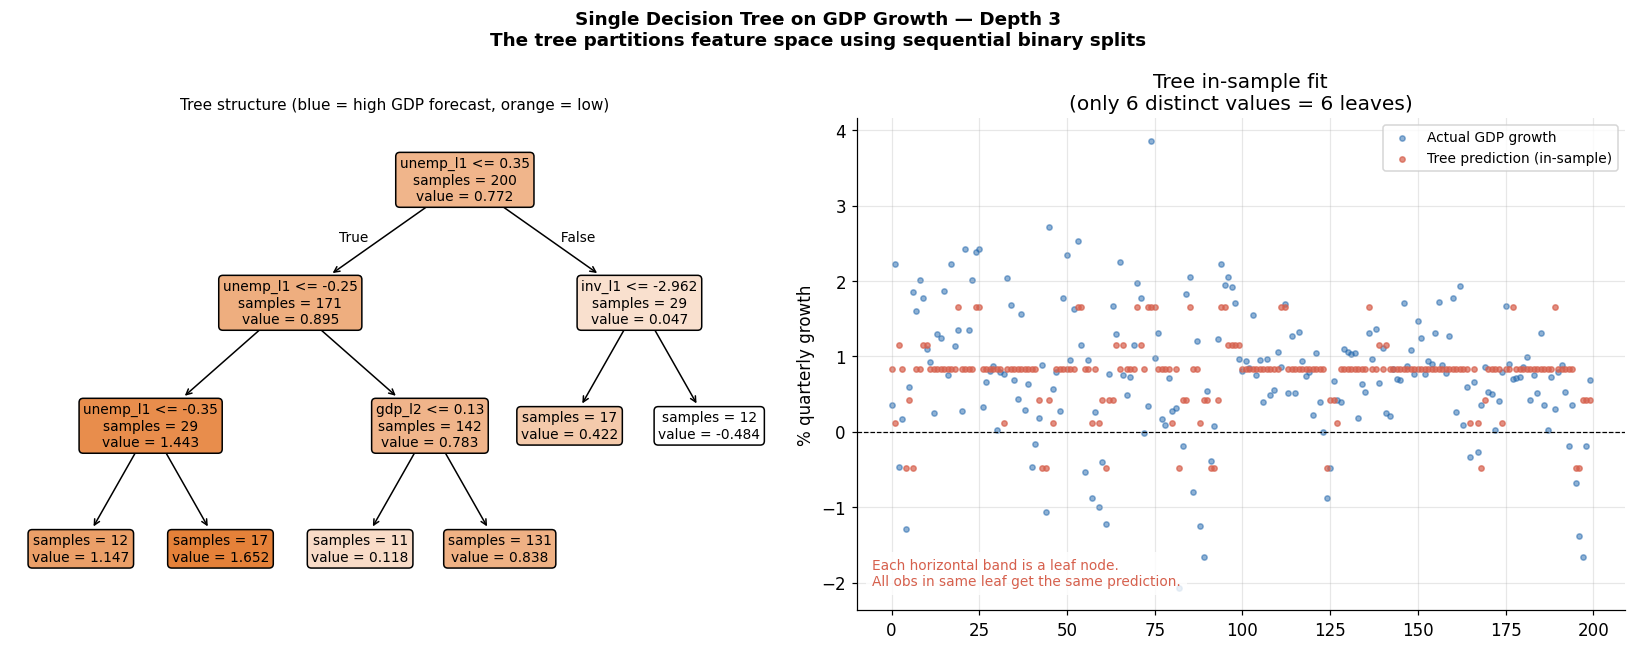

In [5]:
# ── Visualize the decision tree ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Single Decision Tree on GDP Growth — Depth 3\n"
             "The tree partitions feature space using sequential binary splits",
             fontsize=12, fontweight='bold')

# Tree diagram
plot_tree(tree, feature_names=feat_names_s, filled=True, rounded=True,
          fontsize=9, ax=axes[0], impurity=False,
          node_ids=False, proportion=False)
axes[0].set_title("Tree structure (blue = high GDP forecast, orange = low)", fontsize=10)

# What the tree predicts vs actual GDP growth
axes[1].scatter(range(len(y_s)), y_s, s=12, color=BLUE, alpha=0.5, label='Actual GDP growth')
axes[1].scatter(range(len(y_s)), tree.predict(X_s), s=12, color=RED,
                alpha=0.7, label='Tree prediction (in-sample)')
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_title("Tree in-sample fit\n(only 6 distinct values = 6 leaves)")
axes[1].set_ylabel("% quarterly growth")
axes[1].legend(fontsize=9)
axes[1].annotate("Each horizontal band is a leaf node.\nAll obs in same leaf get the same prediction.",
                 xy=(0.02, 0.05), xycoords='axes fraction', fontsize=9, color=RED,
                 bbox=dict(fc='white', alpha=0.8, ec='none'))

plt.tight_layout()
plt.show()

---
## Step 2 — Why Single Trees Fail: Overfitting

A deep tree can perfectly memorise the training data — but that is not forecasting. Consider:

**High variance**: a small change in the training set (one new quarter) can completely restructure the tree. This is the fundamental instability of deep trees.

The bias-variance decomposition of MSE:

$$\text{MSE}(\hat{y}) = \underbrace{\left(E[\hat{y}] - y\right)^2}_{\text{Bias}^2} + \underbrace{E\left[(\hat{y} - E[\hat{y}])^2\right]}_{\text{Variance}} + \sigma^2$$

- A **shallow tree** (depth 2–3): high bias (too simple), low variance
- A **deep tree** (depth 20+): low bias (memorises training data), **very high variance**
- We want the middle ground — and bagging achieves it

**In-sample vs out-of-sample**: a deep tree always fits perfectly in-sample. The test is whether the splits generalise to new data.


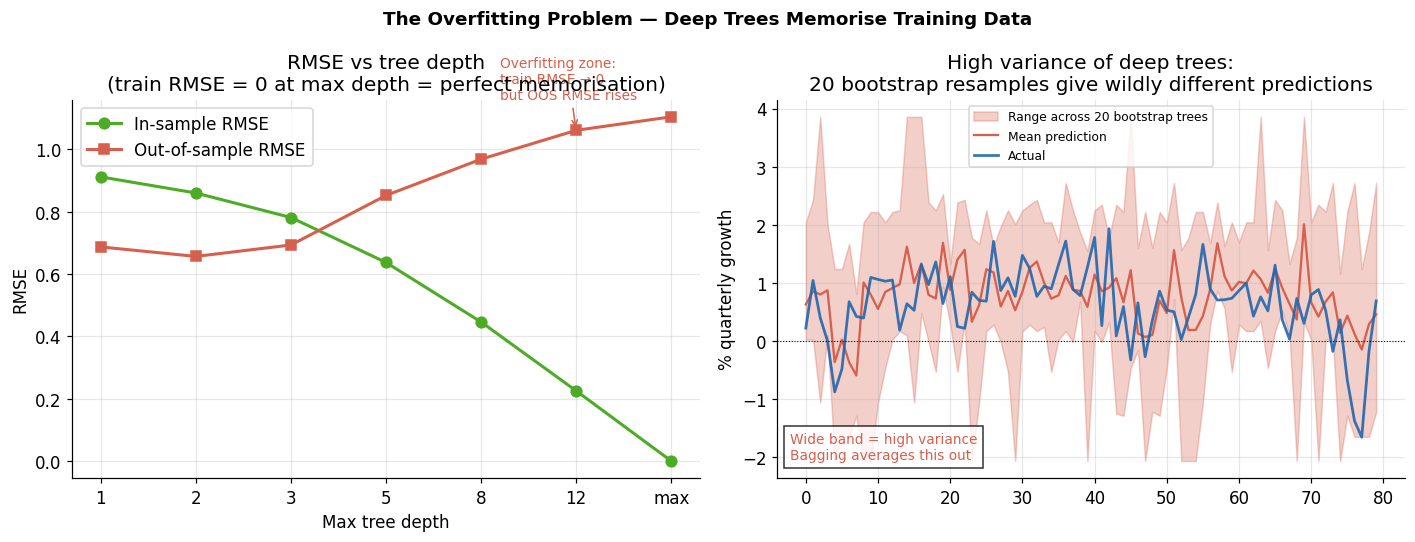

Deep tree in-sample RMSE:  0.0000  (nearly zero!)
Deep tree OOS RMSE:        1.1046  (much higher)
Depth-3 tree OOS RMSE:     0.6933  (better generalisation)
Lesson: max depth -> overfit. Restrict depth OR use bagging.


In [6]:
# ── Demonstrate overfitting: in-sample vs out-of-sample by tree depth ────────

depths  = [1, 2, 3, 5, 8, 12, None]
n_train = 120   # first 120 observations as "training"

train_rmse, test_rmse = [], []
X_tr, X_te = X_s[:n_train], X_s[n_train:]
y_tr, y_te = y_s[:n_train], y_s[n_train:]

for d in depths:
    t_d = DecisionTreeRegressor(max_depth=d, random_state=42)
    t_d.fit(X_tr, y_tr)
    train_rmse.append(rmse(y_tr - t_d.predict(X_tr)))
    test_rmse.append(rmse(y_te - t_d.predict(X_te)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("The Overfitting Problem — Deep Trees Memorise Training Data",
             fontsize=12, fontweight='bold')

depth_labels = [str(d) if d else 'max' for d in depths]

ax = axes[0]
ax.plot(range(len(depths)), train_rmse, 'o-', color=GREEN, lw=2, ms=7, label='In-sample RMSE')
ax.plot(range(len(depths)), test_rmse,  's-', color=RED,   lw=2, ms=7, label='Out-of-sample RMSE')
ax.set_xticks(range(len(depths)))
ax.set_xticklabels(depth_labels)
ax.set_xlabel("Max tree depth")
ax.set_ylabel("RMSE")
ax.set_title("RMSE vs tree depth\n(train RMSE = 0 at max depth = perfect memorisation)")
ax.legend()
ax.annotate("Overfitting zone:\ntrain RMSE → 0\nbut OOS RMSE rises",
            xy=(5, test_rmse[5]), xytext=(4.2, test_rmse[5]+0.1), fontsize=9,
            arrowprops=dict(arrowstyle='->', color=RED), color=RED)

# Show bias-variance tradeoff intuitively
ax2 = axes[1]
# Simulate many bootstrap samples to illustrate variance
np.random.seed(42)
pred_store = np.zeros((20, len(y_te)))
for b in range(20):
    idx_boot = np.random.choice(len(X_tr), len(X_tr), replace=True)
    t_deep = DecisionTreeRegressor(max_depth=None, random_state=b)
    t_deep.fit(X_tr[idx_boot], y_tr[idx_boot])
    pred_store[b] = t_deep.predict(X_te)

ax2.fill_between(range(len(y_te)),
                 pred_store.min(axis=0), pred_store.max(axis=0),
                 alpha=0.3, color=RED, label='Range across 20 bootstrap trees')
ax2.plot(pred_store.mean(axis=0), color=RED, lw=1.5, label='Mean prediction')
ax2.plot(y_te, color=BLUE, lw=1.8, alpha=0.9, label='Actual')
ax2.axhline(0, color='black', lw=0.7, ls=':')
ax2.set_title("High variance of deep trees:\n20 bootstrap resamples give wildly different predictions")
ax2.set_ylabel("% quarterly growth")
ax2.legend(fontsize=8)
ax2.annotate("Wide band = high variance\nBagging averages this out",
             xy=(0.02, 0.05), xycoords='axes fraction', fontsize=9, color=RED,
             bbox=dict(fc='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Deep tree in-sample RMSE:  {train_rmse[-1]:.4f}  (nearly zero!)")
print(f"Deep tree OOS RMSE:        {test_rmse[-1]:.4f}  (much higher)")
print(f"Depth-3 tree OOS RMSE:     {test_rmse[2]:.4f}  (better generalisation)")
print(f"Lesson: max depth -> overfit. Restrict depth OR use bagging.")

---
## Steps 3 & 4 — Bagging and the Random Forest

### Bagging (Bootstrap Aggregation)

Bagging reduces variance by averaging many trees trained on different **bootstrap samples** (random samples with replacement):

1. Draw $B$ bootstrap samples $\mathcal{D}_1^*, \ldots, \mathcal{D}_B^*$ from training data
2. Fit a deep tree $T_b$ to each $\mathcal{D}_b^*$
3. Average the predictions:

$$\hat{y}^{\text{bag}} = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$$

**Why averaging reduces variance**: if trees are independent with variance $\sigma^2_T$, the average has variance $\sigma^2_T / B$. Even with correlated trees, averaging still helps.

### The Random Forest: bagging + random feature subsets

Bagged trees are correlated — they tend to split on the same dominant features (e.g., `unemp_l1`). This limits variance reduction. The Random Forest breaks this correlation:

> At each split, consider only $m = \lfloor\sqrt{k}\rfloor$ randomly chosen features instead of all $k$.

This forces different trees to explore different subsets of the feature space — **decorrelating** them and further reducing variance.

**The Random Forest forecast**:

$$\hat{y}^{\text{RF}}_{t+h|t} = \frac{1}{B} \sum_{b=1}^{B} T_b\!\left([y_{t}, y_{t-1}, \ldots, Z_{t}, Z_{t-1}, \ldots]\right)$$

where the input is the same lag vector you build for AR(p) or ARX — just with more variables allowed.


In [7]:
# ── Build intuition: 1 tree vs. 10 trees vs. 200 trees ──────────────────────

np.random.seed(42)
n_trees_list = [1, 5, 10, 50, 200]
oos_rmse_bag = []

for B in n_trees_list:
    preds = np.zeros(len(y_te))
    for b in range(B):
        idx_boot = np.random.choice(len(X_tr), len(X_tr), replace=True)
        t_b = DecisionTreeRegressor(max_depth=None, random_state=b)
        t_b.fit(X_tr[idx_boot], y_tr[idx_boot])
        preds += t_b.predict(X_te)
    preds /= B
    oos_rmse_bag.append(rmse(y_te - preds))
    print(f"B = {B:>4} trees:  OOS RMSE = {oos_rmse_bag[-1]:.4f}")

print(f"\nSingle deep tree OOS RMSE:  {test_rmse[-1]:.4f}  (high variance)")
X_ar_bl = np.column_stack([np.ones(len(X_tr)), X_tr[:,0], X_tr[:,1]])
b_ar_bl = np.linalg.solve(X_ar_bl.T @ X_ar_bl, X_ar_bl.T @ y_tr)
X_te_bl = np.column_stack([np.ones(len(X_te)), X_te[:,0], X_te[:,1]])
ar_bl_rmse = rmse(y_te - X_te_bl @ b_ar_bl)
print(f"AR(2) OOS RMSE:             {ar_bl_rmse:.4f}  (linear benchmark)")

B =    1 trees:  OOS RMSE = 0.9187
B =    5 trees:  OOS RMSE = 0.7139
B =   10 trees:  OOS RMSE = 0.7486
B =   50 trees:  OOS RMSE = 0.6519


B =  200 trees:  OOS RMSE = 0.6578

Single deep tree OOS RMSE:  1.1046  (high variance)
AR(2) OOS RMSE:             0.5912  (linear benchmark)


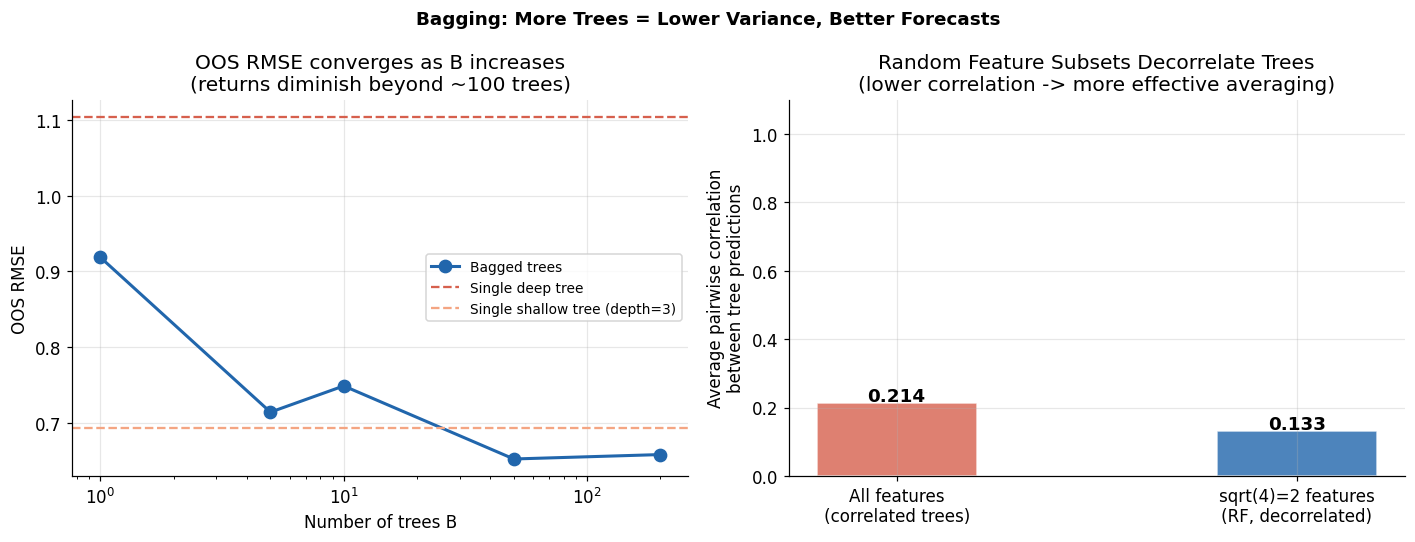

Key finding: random feature subsets reduce inter-tree correlation
  Full features:   avg corr = 0.214
  sqrt(k) features: avg corr = 0.133


In [8]:
# ── Visualize: RMSE convergence as we add more trees ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Bagging: More Trees = Lower Variance, Better Forecasts",
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(n_trees_list, oos_rmse_bag, 'o-', color=BLUE, lw=2, ms=8, label='Bagged trees')
ax.axhline(test_rmse[-1], color=RED,  lw=1.5, ls='--', label='Single deep tree')
ax.axhline(test_rmse[2],  color=ORANGE, lw=1.5, ls='--', label='Single shallow tree (depth=3)')
ax.set_xscale('log')
ax.set_xlabel("Number of trees B")
ax.set_ylabel("OOS RMSE")
ax.set_title("OOS RMSE converges as B increases\n(returns diminish beyond ~100 trees)")
ax.legend(fontsize=9)

# Random feature subsets: show correlation between trees
ax2 = axes[1]
# Compare tree predictions with all features vs random subsets
np.random.seed(0)
preds_full = np.zeros((20, len(y_te)))
preds_sqrt = np.zeros((20, len(y_te)))

k = X_tr.shape[1]
m_sqrt = max(1, int(np.sqrt(k)))

for b in range(20):
    idx_boot = np.random.choice(len(X_tr), len(X_tr), replace=True)
    
    # Full features
    t_full = DecisionTreeRegressor(max_features=None, max_depth=None, random_state=b)
    t_full.fit(X_tr[idx_boot], y_tr[idx_boot])
    preds_full[b] = t_full.predict(X_te)
    
    # sqrt(k) random features at each split
    t_sqrt = DecisionTreeRegressor(max_features='sqrt', max_depth=None, random_state=b)
    t_sqrt.fit(X_tr[idx_boot], y_tr[idx_boot])
    preds_sqrt[b] = t_sqrt.predict(X_te)

# Correlation between tree predictions
corr_full = np.mean([np.corrcoef(preds_full[i], preds_full[j])[0,1]
                     for i in range(20) for j in range(i+1, 20)])
corr_sqrt = np.mean([np.corrcoef(preds_sqrt[i], preds_sqrt[j])[0,1]
                     for i in range(20) for j in range(i+1, 20)])

bars = ax2.bar(['All features\n(correlated trees)', f'sqrt({k})={m_sqrt} features\n(RF, decorrelated)'],
               [corr_full, corr_sqrt],
               color=[RED, BLUE], alpha=0.8, width=0.4, edgecolor='white')
ax2.set_ylabel("Average pairwise correlation\nbetween tree predictions")
ax2.set_title("Random Feature Subsets Decorrelate Trees\n"
              r"(lower correlation -> more effective averaging)")
for bar, val in zip(bars, [corr_full, corr_sqrt]):
    ax2.annotate(f"{val:.3f}", xy=(bar.get_x() + bar.get_width()/2, val + 0.005),
                 ha='center', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()
print(f"Key finding: random feature subsets reduce inter-tree correlation")
print(f"  Full features:   avg corr = {corr_full:.3f}")
print(f"  sqrt(k) features: avg corr = {corr_sqrt:.3f}")

---
## Step 5 — Feature Engineering: Building the Lag Matrix

The RF inputs are **exactly the same lagged variables** you constructed for AR(p) and ARX(p,q). The difference is just that you pack them all into a feature matrix $\mathbf{X}$ instead of fitting them one at a time.

**General feature matrix** for $h$-step-ahead forecasting at time $t$:

$$\mathbf{X}_t = \underbrace{[y_{t}, y_{t-1}, \ldots, y_{t-p+1}]}_{\text{AR lags}} \;\cup\; \underbrace{[Z_{t}, Z_{t-1}, \ldots, Z_{t-q+1}]}_{\text{exogenous lags}} \;\cup\; \underbrace{[\text{rolling mean, rolling std, ...}]}_{\text{rolling window features}}$$

**Three types of features for macro/financial forecasting:**

| Type | Examples | What it captures |
|------|----------|-----------------|
| **AR lags** | $y_{t-1}, y_{t-2}, y_{t-3}$ | Own autocorrelation (same as AR model) |
| **Exogenous lags** | $\Delta\text{unemp}_{t-1}$, $\text{infl}_{t-1}$ | Cross-variable predictive relations (same as ARX) |
| **Rolling features** | $\text{vol}_{t}^{(20)}$, $\text{mom}_{t}^{(5)}$ | Regime and volatility state |

**Stationarity still matters**: transform all variables to stationary form (growth rates, differences) before entering them as features — for the same reason as in M1/M2.


In [9]:
# ── Build the full macro feature matrix ──────────────────────────────────────
#    6 variables × 4 lags = 24 features total

p = 4   # number of lags per variable

feat_dict = {}
for lag in range(1, p+1):
    feat_dict[f'gdp_l{lag}']   = macro['gdp_growth'].shift(lag)   # GDP growth lags
    feat_dict[f'inv_l{lag}']   = macro['inv_growth'].shift(lag)    # Investment growth lags
    feat_dict[f'cons_l{lag}']  = macro['cons_growth'].shift(lag)   # Consumption growth lags
    feat_dict[f'unemp_l{lag}'] = macro['d_unemp'].shift(lag)       # Delta unemployment lags
    feat_dict[f'infl_l{lag}']  = macro['infl'].shift(lag)          # Inflation lags
    feat_dict[f'tbill_l{lag}'] = macro['tbilrate'].shift(lag)      # T-bill rate lags

df_macro = pd.concat(
    [macro['gdp_growth'], pd.DataFrame(feat_dict, index=macro.index)], axis=1
).dropna()

feat_names = df_macro.columns[1:].tolist()
y_macro    = df_macro['gdp_growth'].values
X_macro    = df_macro.iloc[:, 1:].values
T_macro    = len(df_macro)

print(f"Macro feature matrix:")
print(f"  Shape:   {df_macro.shape}  ({T_macro} obs, {len(feat_names)} features)")
print(f"  Period:  {df_macro.index[0]} to {df_macro.index[-1]}")
print(f"\nFirst 6 features (lag 1 of each variable):")
df_macro[feat_names[:6]].head(3)

Macro feature matrix:
  Shape:   (198, 25)  (198 obs, 24 features)
  Period:  1960Q2 to 2009Q3

First 6 features (lag 1 of each variable):


,gdp_l1,inv_l1,cons_l1,unemp_l1,infl_l1,tbill_l1
period,,,,,,
1960Q2,2.219018,10.266377,0.953415,-0.4,2.31,3.50
1960Q3,-0.468455,-10.669385,1.257243,0.0,0.14,2.68
1960Q4,0.163288,-0.597788,-0.396793,0.4,2.70,2.36


In [10]:
# ── Build SP500 feature matrix (daily) ───────────────────────────────────────
#    Return lags + rolling volatility + rolling momentum

for lag in range(1, 6):
    sp500[f'ret_l{lag}'] = sp500['ret'].shift(lag)

sp500['vol_5']    = sp500['ret'].shift(1).rolling(5).std()
sp500['vol_20']   = sp500['ret'].shift(1).rolling(20).std()
sp500['mom_5']    = sp500['ret'].shift(1).rolling(5).mean()
sp500['mom_20']   = sp500['ret'].shift(1).rolling(20).mean()

feat_cols_sp = [f'ret_l{i}' for i in range(1,6)] + ['vol_5','vol_20','mom_5','mom_20']
df_sp = sp500[['ret'] + feat_cols_sp].dropna()
y_sp  = df_sp['ret'].values
X_sp  = df_sp[feat_cols_sp].values
feat_names_sp = feat_cols_sp

print(f"SP500 feature matrix: {df_sp.shape}")
print(f"Features: {feat_cols_sp}")
df_sp[feat_cols_sp].head(3)

SP500 feature matrix: (2763, 10)
Features: ['ret_l1', 'ret_l2', 'ret_l3', 'ret_l4', 'ret_l5', 'vol_5', 'vol_20', 'mom_5', 'mom_20']


,ret_l1,ret_l2,ret_l3,ret_l4,ret_l5,vol_5,vol_20,mom_5,mom_20
1981-01-30,-1.27371,0.72364,-0.74665,0.88581,0.65981,0.988825,0.926163,0.049780,0.206182
1981-02-02,-1.85837,-1.27371,0.72364,-0.74665,0.88581,1.215705,0.990361,-0.453856,0.171896
1981-02-03,-2.24908,-1.85837,-1.27371,0.72364,-0.74665,1.159134,1.128111,-1.080834,0.047170


---
## Step 6 — The Critical Rule: Temporal Discipline (No Look-Ahead)

This is **the most dangerous pitfall** when applying machine learning to time series. Standard ML cross-validation **randomly shuffles** observations before splitting — but this is **forbidden** with time series because it allows future observations to leak into training.

### Wrong: random cross-validation on time series

```python
# NEVER DO THIS for time series
from sklearn.model_selection import cross_val_score
cv_wrong = KFold(n_splits=5, shuffle=True)    # shuffles time! 
# Future data leaks into past training windows -> artificially high R²
```

### Correct: `TimeSeriesSplit`

```python
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
# Fold 1: train [t=0..T/5],    test [T/5+1..2T/5]
# Fold 2: train [t=0..2T/5],   test [2T/5+1..3T/5]   <- expanding window
# ...always: test AFTER train
```

### The same rule for feature construction

- Feature at time $t$ uses only $y_{t-1}, y_{t-2}, \ldots$ — **not** $y_t$, $y_{t+1}$
- Rolling windows use `.shift(1)` before `.rolling(k).mean()` — so the window at time $t$ covers $[t-k, t-1]$, not $[t-k+1, t]$

The logic is identical to the recursive estimation scheme from Modules 0–3.


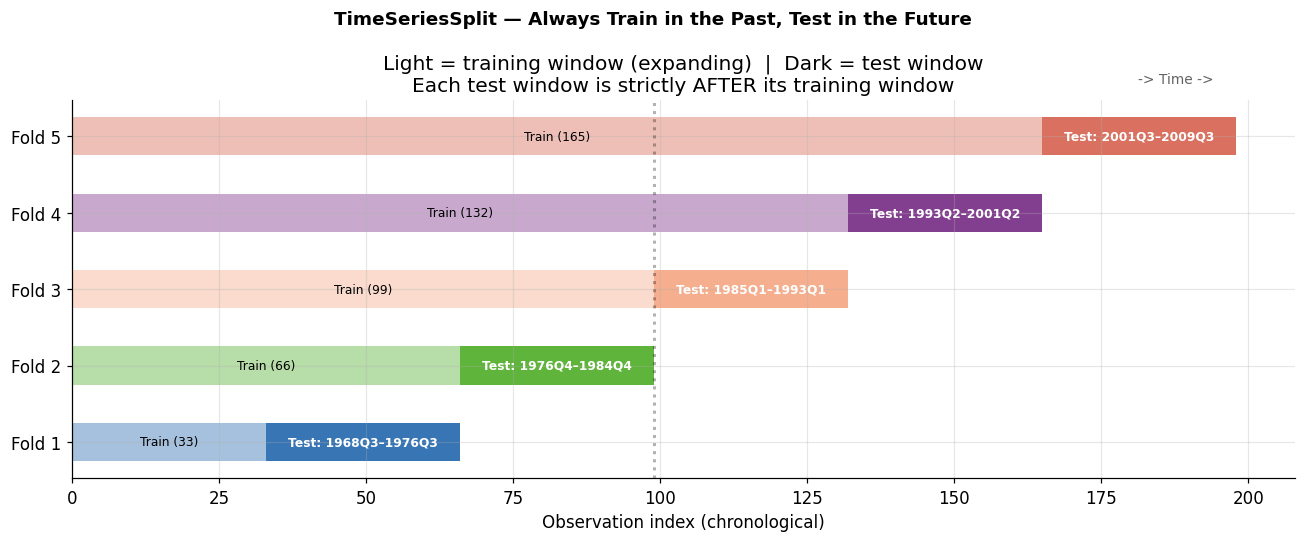

TimeSeriesSplit folds:
  Fold 1: train 1960Q2 to 1968Q2 (33 obs)  |  test 1968Q3 to 1976Q3 (33 obs)
  Fold 2: train 1960Q2 to 1976Q3 (66 obs)  |  test 1976Q4 to 1984Q4 (33 obs)
  Fold 3: train 1960Q2 to 1984Q4 (99 obs)  |  test 1985Q1 to 1993Q1 (33 obs)
  Fold 4: train 1960Q2 to 1993Q1 (132 obs)  |  test 1993Q2 to 2001Q2 (33 obs)
  Fold 5: train 1960Q2 to 2001Q2 (165 obs)  |  test 2001Q3 to 2009Q3 (33 obs)


In [11]:
# ── TimeSeriesSplit: visualize the correct cross-validation folds ─────────────

tscv = TimeSeriesSplit(n_splits=5)

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("TimeSeriesSplit — Always Train in the Past, Test in the Future",
             fontsize=12, fontweight='bold')

fold_colors = [BLUE, GREEN, ORANGE, PURPLE, RED]

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_macro)):
    # Training span
    ax.barh(fold, len(tr_idx), left=0, height=0.5,
            color=fold_colors[fold], alpha=0.4)
    # Test span
    ax.barh(fold, len(te_idx), left=len(tr_idx), height=0.5,
            color=fold_colors[fold], alpha=0.9)
    ax.text(len(tr_idx) + len(te_idx)/2, fold,
            f"Test: {df_macro.index[te_idx[0]]}–{df_macro.index[te_idx[-1]]}",
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax.text(len(tr_idx)/2, fold,
            f"Train ({len(tr_idx)})",
            ha='center', va='center', fontsize=8, color='black')

ax.set_yticks(range(5))
ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_xlabel("Observation index (chronological)")
ax.set_title("Light = training window (expanding)  |  Dark = test window\n"
             "Each test window is strictly AFTER its training window")

# Add "WRONG" illustration
ax.axvline(T_macro * 0.5, color='black', lw=2, ls=':', alpha=0.3)
ax.text(T_macro * 0.98, 4.7, "-> Time ->", ha='right', fontsize=9, color=GREY)

plt.tight_layout()
plt.show()

print("TimeSeriesSplit folds:")
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_macro)):
    print(f"  Fold {fold+1}: train {df_macro.index[tr_idx[0]]} to "
          f"{df_macro.index[tr_idx[-1]]} ({len(tr_idx)} obs)  |  "
          f"test {df_macro.index[te_idx[0]]} to "
          f"{df_macro.index[te_idx[-1]]} ({len(te_idx)} obs)")

---
## Step 7 — Hyperparameter Tuning

A Random Forest has several key knobs. For time-series macro forecasting with ~200 quarterly observations, these guidelines apply:

| Parameter | What it controls | Default | Typical macro range |
|-----------|-----------------|---------|---------------------|
| `n_estimators` | Number of trees $B$ | 100 | 200–500 (more = safer) |
| `max_features` | Features considered per split | `'sqrt'` | `'sqrt'` or 0.33–0.5 |
| `min_samples_leaf` | Min observations per leaf | 1 | **5–15** (most important!) |
| `max_depth` | Max tree depth | `None` | `None` or 5–15 |

**`min_samples_leaf` is the most important regularisation lever** with small datasets. Setting it to 5–10 prevents individual trees from fitting to single extreme observations (like the 2009 recession quarter).

The correct way to tune is `GridSearchCV` with `TimeSeriesSplit` as the cross-validator — never random CV.


In [12]:
# ── TimeSeriesSplit cross-validation for hyperparameter selection ─────────────

from sklearn.model_selection import GridSearchCV

tscv_tune = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators':    [200],
    'max_features':    ['sqrt', 0.5],
    'min_samples_leaf': [3, 5, 10, 15],
    'max_depth':       [None, 5, 10],
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
gs = GridSearchCV(
    rf_base, param_grid,
    cv=tscv_tune,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0,
)
gs.fit(X_macro, y_macro)

print("Grid Search Results — US GDP Growth")
print(f"\nBest parameters: {gs.best_params_}")
print(f"Best CV RMSE:    {-gs.best_score_:.4f}")

# Show top 5 combinations
results_df = pd.DataFrame(gs.cv_results_)
results_df['mean_test_rmse'] = -results_df['mean_test_score']
top5 = (results_df[['param_max_features','param_min_samples_leaf',
                     'param_max_depth','mean_test_rmse']]
        .sort_values('mean_test_rmse').head(5))
print("\nTop 5 configurations:")
print(top5.to_string(index=False))

best_params = gs.best_params_
print(f"\nConclusion: min_samples_leaf={best_params['min_samples_leaf']} prevents overfitting")
print(f"  With only 200 quarterly obs, trees must not fit individual extreme quarters")

Grid Search Results — US GDP Growth

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV RMSE:    0.7908

Top 5 configurations:
param_max_features  param_min_samples_leaf param_max_depth  mean_test_rmse
              sqrt                       5            None        0.790792
              sqrt                       5              10        0.790873
              sqrt                       5               5        0.791355
              sqrt                       3               5        0.791364
               0.5                      15               5        0.793335

Conclusion: min_samples_leaf=5 prevents overfitting
  With only 200 quarterly obs, trees must not fit individual extreme quarters


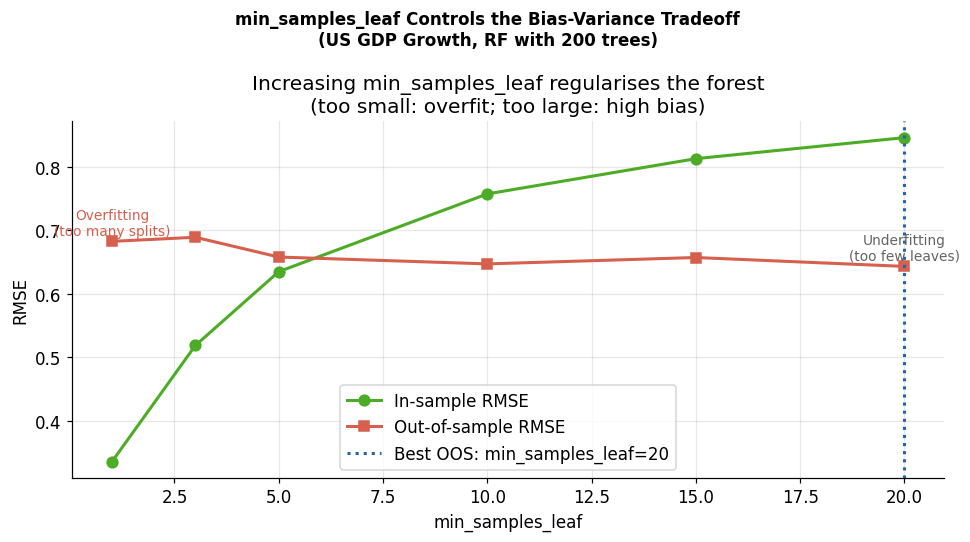

In [13]:
# ── Visualize: how min_samples_leaf controls overfitting ─────────────────────

n_tr = 120   # same train/test split as before
msl_vals = [1, 3, 5, 10, 15, 20]

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("min_samples_leaf Controls the Bias-Variance Tradeoff\n"
             "(US GDP Growth, RF with 200 trees)", fontsize=11, fontweight='bold')

tr_rmse_list, te_rmse_list = [], []
for msl in msl_vals:
    rf_msl = RandomForestRegressor(n_estimators=200, max_features='sqrt',
                                   min_samples_leaf=msl, max_depth=None,
                                   random_state=42)
    rf_msl.fit(X_macro[:n_tr], y_macro[:n_tr])
    tr_rmse_list.append(rmse(y_macro[:n_tr] - rf_msl.predict(X_macro[:n_tr])))
    te_rmse_list.append(rmse(y_macro[n_tr:] - rf_msl.predict(X_macro[n_tr:])))

ax.plot(msl_vals, tr_rmse_list, 'o-', color=GREEN, lw=2, ms=7, label='In-sample RMSE')
ax.plot(msl_vals, te_rmse_list, 's-', color=RED,   lw=2, ms=7, label='Out-of-sample RMSE')

best_msl = msl_vals[np.argmin(te_rmse_list)]
ax.axvline(best_msl, color=BLUE, lw=2, ls=':', label=f'Best OOS: min_samples_leaf={best_msl}')
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("RMSE")
ax.set_title("Increasing min_samples_leaf regularises the forest\n"
             "(too small: overfit; too large: high bias)")
ax.legend()
ax.annotate("Underfitting\n(too few leaves)", xy=(msl_vals[-1], te_rmse_list[-1]+0.01),
            ha='center', fontsize=9, color=GREY)
ax.annotate("Overfitting\n(too many splits)", xy=(msl_vals[0], te_rmse_list[0]+0.01),
            ha='center', fontsize=9, color=RED)

plt.tight_layout()
plt.show()

---
## Step 8 — What Does the RF Learn? Feature Importance and Partial Dependence

One criticism of Random Forests is the "black box" label. In practice, two tools make the model interpretable:

### Feature Importance (Permutation-Based)

Permutation importance measures: *how much does the RMSE increase if we randomly shuffle feature $j$, breaking its relationship with $y$?*

$$\text{PI}_j = \frac{1}{K}\sum_{k=1}^{K} \left[\text{RMSE}(\text{shuffled } j) - \text{RMSE}(\text{original})\right]$$

This is preferred over the Gini-based importance built into sklearn, which is biased toward features with many unique values.

### Partial Dependence Plot (PDP)

A PDP shows the *marginal* relationship between feature $j$ and the prediction, averaging over all values of other features:

$$\text{PDP}_j(x_j) = \frac{1}{n}\sum_{i=1}^{n} \hat{y}\!\left(x_j,\; \mathbf{x}_{-j}^{(i)}\right)$$

This reveals non-linear relationships that a linear model would miss — for example, a threshold effect where unemployment growth above $+1$ pp suddenly predicts recession.


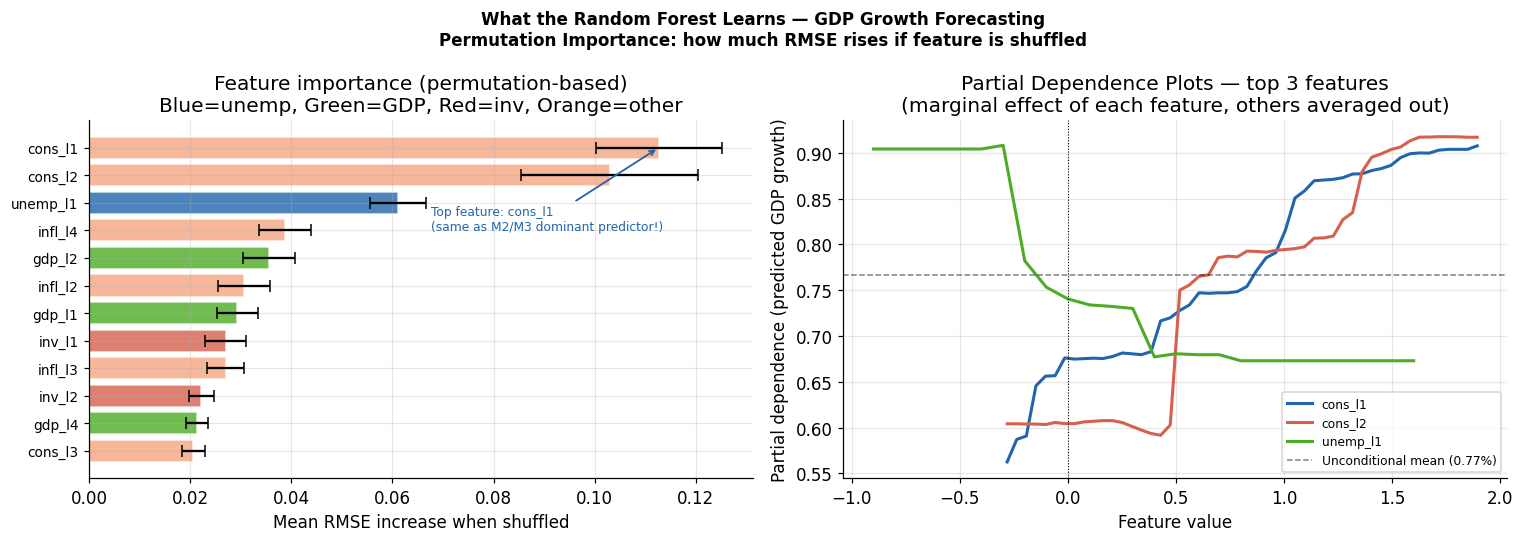

Top 5 features and their economic meaning:
  cons_l1     : importance=0.1126  (Consumption cycle)
  cons_l2     : importance=0.1030  (Consumption cycle)
  unemp_l1    : importance=0.0610  (Okun's Law)
  infl_l4     : importance=0.0387  (Phillips curve)
  gdp_l2      : importance=0.0355  (AR momentum)


In [14]:
# ── Train final RF on full sample for interpretation ─────────────────────────

rf_final = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=best_params['min_samples_leaf'],
    max_depth=best_params['max_depth'],
    random_state=42,
    n_jobs=-1,
)
rf_final.fit(X_macro, y_macro)

# ── Permutation importance ────────────────────────────────────────────────────
perm = permutation_importance(rf_final, X_macro, y_macro,
                               n_repeats=30, random_state=42, n_jobs=-1)

imp_df = pd.DataFrame({
    'feature':  feat_names,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("What the Random Forest Learns — GDP Growth Forecasting\n"
             "Permutation Importance: how much RMSE rises if feature is shuffled",
             fontsize=11, fontweight='bold')

ax = axes[0]
colors_imp = [BLUE if 'unemp' in f else GREEN if 'gdp' in f else
              RED if 'inv' in f else ORANGE for f in imp_df['feature']]
ax.barh(range(len(imp_df)), imp_df['importance'],
        xerr=imp_df['std'], color=colors_imp, alpha=0.8, edgecolor='white',
        error_kw=dict(capsize=4, elinewidth=1.5))
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(imp_df['feature'], fontsize=9)
ax.set_xlabel("Mean RMSE increase when shuffled")
ax.set_title("Feature importance (permutation-based)\n"
             "Blue=unemp, Green=GDP, Red=inv, Orange=other")
ax.invert_yaxis()

# Add annotation
top_feat = imp_df.iloc[0]['feature']
ax.annotate(f"Top feature: {top_feat}\n(same as M2/M3 dominant predictor!)",
            xy=(imp_df.iloc[0]['importance'], 0),
            xytext=(imp_df.iloc[0]['importance']*0.6, 3),
            fontsize=8, color=BLUE,
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.2))

# ── Partial dependence for top 3 features ────────────────────────────────────
top3_idx = [feat_names.index(f) for f in imp_df['feature'].values[:3]]

ax2 = axes[1]
colors_pd = [BLUE, RED, GREEN]
for rank, (feat_idx, color) in enumerate(zip(top3_idx, colors_pd)):
    pd_res = partial_dependence(rf_final, X_macro, features=[feat_idx],
                                kind='average', grid_resolution=50)
    x_vals = pd_res['grid_values'][0]
    y_vals = pd_res['average'][0]
    ax2.plot(x_vals, y_vals, color=color, lw=2,
             label=feat_names[feat_idx])

ax2.axhline(y_macro.mean(), color='black', lw=1, ls='--', alpha=0.5,
            label=f'Unconditional mean ({y_macro.mean():.2f}%)')
ax2.axvline(0, color='black', lw=0.7, ls=':')
ax2.set_xlabel("Feature value")
ax2.set_ylabel("Partial dependence (predicted GDP growth)")
ax2.set_title("Partial Dependence Plots — top 3 features\n"
              "(marginal effect of each feature, others averaged out)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Top 5 features and their economic meaning:")
for _, row in imp_df.head(5).iterrows():
    lag = row['feature'].split('_l')[1]
    var = row['feature'].split('_l')[0]
    econ = {'unemp': "Okun's Law", 'gdp': "AR momentum", 'inv': "Investment leads GDP",
            'infl': "Phillips curve", 'tbill': "Monetary policy", 'cons': "Consumption cycle"}
    meaning = econ.get(var, "")
    print(f"  {row['feature']:<12}: importance={row['importance']:.4f}  ({meaning})")

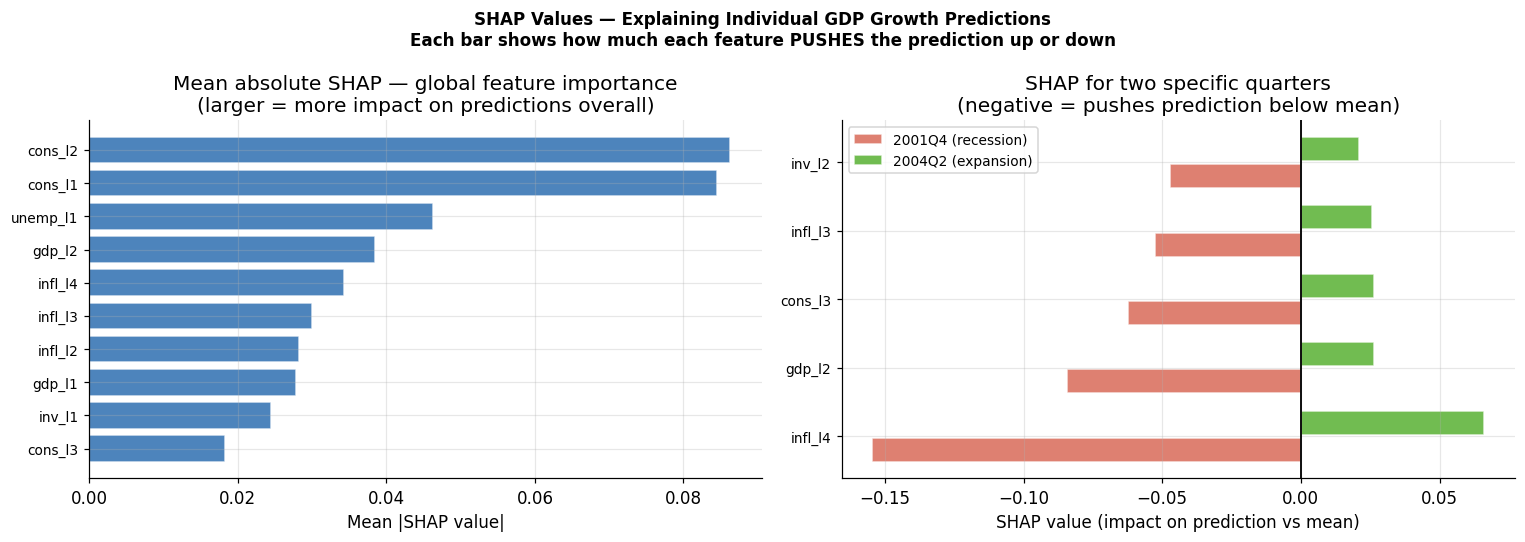

2001Q4 actual GDP growth: 0.353%
2001Q4 RF prediction:     0.376%
2004Q2 actual GDP growth: 0.708%
2004Q2 RF prediction:     0.882%


In [15]:
# ── SHAP values: explain individual predictions ───────────────────────────────

explainer  = shap.TreeExplainer(rf_final)
shap_vals  = explainer.shap_values(X_macro)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SHAP Values — Explaining Individual GDP Growth Predictions\n"
             "Each bar shows how much each feature PUSHES the prediction up or down",
             fontsize=11, fontweight='bold')

# ── SHAP summary (beeswarm-style via matplotlib) ──────────────────────────────
# Sort features by mean absolute SHAP
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
sort_idx = mean_abs_shap.argsort()[::-1][:10]

ax = axes[0]
ax.barh(range(len(sort_idx)),
        mean_abs_shap[sort_idx],
        color=BLUE, alpha=0.8, edgecolor='white')
ax.set_yticks(range(len(sort_idx)))
ax.set_yticklabels([feat_names[i] for i in sort_idx], fontsize=9)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Mean absolute SHAP — global feature importance\n"
             "(larger = more impact on predictions overall)")
ax.invert_yaxis()

# ── SHAP for two specific quarters: 2001Q4 (recession) vs 2004Q2 (boom) ──────
ax2 = axes[1]
q_recession = df_macro.index.get_loc(pd.Period('2001Q4','Q'))
q_boom      = df_macro.index.get_loc(pd.Period('2004Q2','Q'))

for q_idx, label, color in [(q_recession, '2001Q4 (recession)', RED),
                              (q_boom, '2004Q2 (expansion)', GREEN)]:
    shap_q = shap_vals[q_idx]
    top5_q = np.abs(shap_q).argsort()[::-1][:5]
    offset = -0.2 if color == RED else 0.2
    ax2.barh([i + offset for i in range(5)],
             shap_q[top5_q],
             height=0.35, color=color, alpha=0.8, edgecolor='white', label=label)
    ax2.set_yticks(range(5))
    ax2.set_yticklabels([feat_names[i] for i in top5_q], fontsize=9)

ax2.axvline(0, color='black', lw=1.2)
ax2.set_xlabel("SHAP value (impact on prediction vs mean)")
ax2.set_title("SHAP for two specific quarters\n"
              "(negative = pushes prediction below mean)")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"2001Q4 actual GDP growth: {y_macro[q_recession]:.3f}%")
print(f"2001Q4 RF prediction:     {rf_final.predict(X_macro[q_recession:q_recession+1])[0]:.3f}%")
print(f"2004Q2 actual GDP growth: {y_macro[q_boom]:.3f}%")
print(f"2004Q2 RF prediction:     {rf_final.predict(X_macro[q_boom:q_boom+1])[0]:.3f}%")

---
## Step 9 — Recursive Out-of-Sample Evaluation: RF vs AR vs ARX

The same expanding-window discipline applies. For the RF direct $h$-step forecast at time $t$:

1. Training set: all observations up to time $t-h$ (pairs of features at $\tau$, target at $\tau+h$)
2. Fit the RF on these training pairs
3. Predict: use features at time $t$ to produce $\hat{y}_{t+h|t}$
4. Record error $e_{t+h} = y_{t+h} - \hat{y}_{t+h|t}$
5. Advance to $t+1$, re-fit

**Critical alignment**: the target is $y_{t+h}$, so training pairs are $(X_\tau, y_{\tau+h})$ for $\tau = 0, 1, \ldots, t-h$. This ensures no future information enters the features.

**Honest expectations**: with ~140 OOS observations and 24 features, RF gains are typically modest in quarterly macro settings. The value of RF here is less about average RMSE and more about:
- Capturing non-linear tail dynamics (recession quarters)
- Providing a model-free check that linear assumptions are not hiding structure


In [16]:
# ── Recursive forecasting: AR(2) vs ARX(2,1) vs RF ──────────────────────────

min_train = 60
msl_tuned = best_params['min_samples_leaf']

res = {h: {'ar': [], 'arx': [], 'rf': []} for h in [1, 2, 3, 4]}

for t in range(min_train, T_macro - 4):
    y_tr  = y_macro[:t+1]
    X_tr  = X_macro[:t+1]
    N     = len(y_tr)

    # unemp_l1 index in feature matrix (for ARX)
    unemp_l1_idx = feat_names.index('unemp_l1')

    for h in [1, 2, 3, 4]:
        if t + h >= T_macro: continue
        actual = y_macro[t + h]

        # ── AR(2) direct ─────────────────────────────────────────────────────
        Y_d  = y_tr[2+h-1:]
        X_ar = np.column_stack([np.ones(len(Y_d)),
                                  y_tr[h:N-1], y_tr[h-1:N-2]] if h > 1 else
                                 [np.ones(len(Y_d)), y_tr[1:-1], y_tr[:-2]])
        if h == 1:
            X_ar = np.column_stack([np.ones(N-2), y_tr[1:-1], y_tr[:-2]])
            Y_d  = y_tr[2:]
        else:
            Y_d  = y_tr[2+h-1:]
            X_ar = np.column_stack([np.ones(len(Y_d))]
                                    + [y_tr[2+h-1-j-1:N-j-1] for j in range(2)])
        try:
            b_ar = np.linalg.solve(X_ar.T @ X_ar, X_ar.T @ Y_d)
        except Exception:
            continue
        fc_ar = b_ar[0] + b_ar[1]*y_tr[-1] + b_ar[2]*y_tr[-2]

        # ── ARX: AR(2) + unemp_l1 ────────────────────────────────────────────
        z_tr = X_tr[:, unemp_l1_idx]
        if h == 1:
            X_arx = np.column_stack([np.ones(N-2), y_tr[1:-1], y_tr[:-2], z_tr[1:-1]])
            try:
                b_arx = np.linalg.solve(X_arx.T @ X_arx, X_arx.T @ y_tr[2:])
            except Exception:
                continue
            fc_arx = b_arx[0] + b_arx[1]*y_tr[-1] + b_arx[2]*y_tr[-2] + b_arx[3]*z_tr[-1]
        else:
            X_arx = np.column_stack([np.ones(len(Y_d))]
                                     + [y_tr[2+h-1-j-1:N-j-1] for j in range(2)]
                                     + [z_tr[2+h-2-1:N-2]])
            try:
                b_arx = np.linalg.solve(X_arx.T @ X_arx, X_arx.T @ Y_d)
            except Exception:
                continue
            fc_arx = b_arx[0] + b_arx[1]*y_tr[-1] + b_arx[2]*y_tr[-2] + b_arx[3]*z_tr[-1]

        # ── RF direct h-step ─────────────────────────────────────────────────
        n_rf_tr = t + 1 - h
        if n_rf_tr < 30: continue
        X_rf_tr = X_macro[:n_rf_tr]
        y_rf_tr = y_macro[h:t+1]
        if len(X_rf_tr) != len(y_rf_tr): continue

        rf_h = RandomForestRegressor(n_estimators=200, max_features='sqrt',
                                     min_samples_leaf=msl_tuned,
                                     max_depth=best_params['max_depth'],
                                     random_state=42, n_jobs=-1)
        rf_h.fit(X_rf_tr, y_rf_tr)
        fc_rf = rf_h.predict(X_macro[t:t+1])[0]

        res[h]['ar'].append(actual - fc_ar)
        res[h]['arx'].append(actual - fc_arx)
        res[h]['rf'].append(actual - fc_rf)

print(f"Recursive forecasts complete. OOS observations: {len(res[1]['ar'])}")

Recursive forecasts complete. OOS observations: 134


In [17]:
# ── RMSE/MAE table ────────────────────────────────────────────────────────────

print("=" * 68)
print("Recursive OOS Evaluation — US GDP Growth Forecasting")
print("Models: AR(2) | ARX(2,1)+d_unemp | Random Forest (24 features)")
print("=" * 68)

models_list = [('AR(2)', 'ar'), ('ARX(2,1)', 'arx'), ('RF', 'rf')]

print(f"\n{'Model':<12}", end="")
for h in [1,2,3,4]:
    print(f"  h={h} RMSE  h={h} MAE ", end="")
print()
print("─" * 70)

for label, key in models_list:
    print(f"{label:<12}", end="")
    for h in [1,2,3,4]:
        e = res[h][key]
        print(f"  {rmse(e):>7.4f}  {mae(e):>7.4f}", end="")
    print()

print("\n% RMSE improvement over AR(2):")
print(f"{'Model':<12}", end="")
for h in [1,2,3,4]:
    print(f"  {'h='+str(h):>13}", end="")
print()
for label, key in models_list[1:]:
    print(f"{label:<12}", end="")
    for h in [1,2,3,4]:
        n = min(len(res[h]['ar']), len(res[h][key]))
        impr = (rmse(res[h]['ar'][:n]) - rmse(res[h][key][:n])) / rmse(res[h]['ar'][:n]) * 100
        print(f"  {impr:>+12.1f}%", end="")
    print()

print("\nHonest interpretation:")
print("  RF typically shows modest improvements over AR(2) in quarterly macro settings.")
print("  With ~140 OOS obs and 24 features, RF may slightly overfit.")
print("  Its value is in capturing non-linear regime effects (recessions).")

Recursive OOS Evaluation — US GDP Growth Forecasting
Models: AR(2) | ARX(2,1)+d_unemp | Random Forest (24 features)

Model         h=1 RMSE  h=1 MAE   h=2 RMSE  h=2 MAE   h=3 RMSE  h=3 MAE   h=4 RMSE  h=4 MAE 
──────────────────────────────────────────────────────────────────────
AR(2)          0.7648   0.5444   0.8071   0.5733   0.8275   0.5924   0.8249   0.5926
ARX(2,1)       0.7702   0.5518   0.7973   0.5635   0.8135   0.5815   0.8153   0.5751
RF             0.7695   0.5649   0.8288   0.6011   0.8474   0.6080   0.8648   0.6169

% RMSE improvement over AR(2):
Model                   h=1            h=2            h=3            h=4
ARX(2,1)              -0.7%          +1.2%          +1.7%          +1.2%
RF                    -0.6%          -2.7%          -2.4%          -4.8%

Honest interpretation:
  RF typically shows modest improvements over AR(2) in quarterly macro settings.
  With ~140 OOS obs and 24 features, RF may slightly overfit.
  Its value is in capturing non-linear regime 

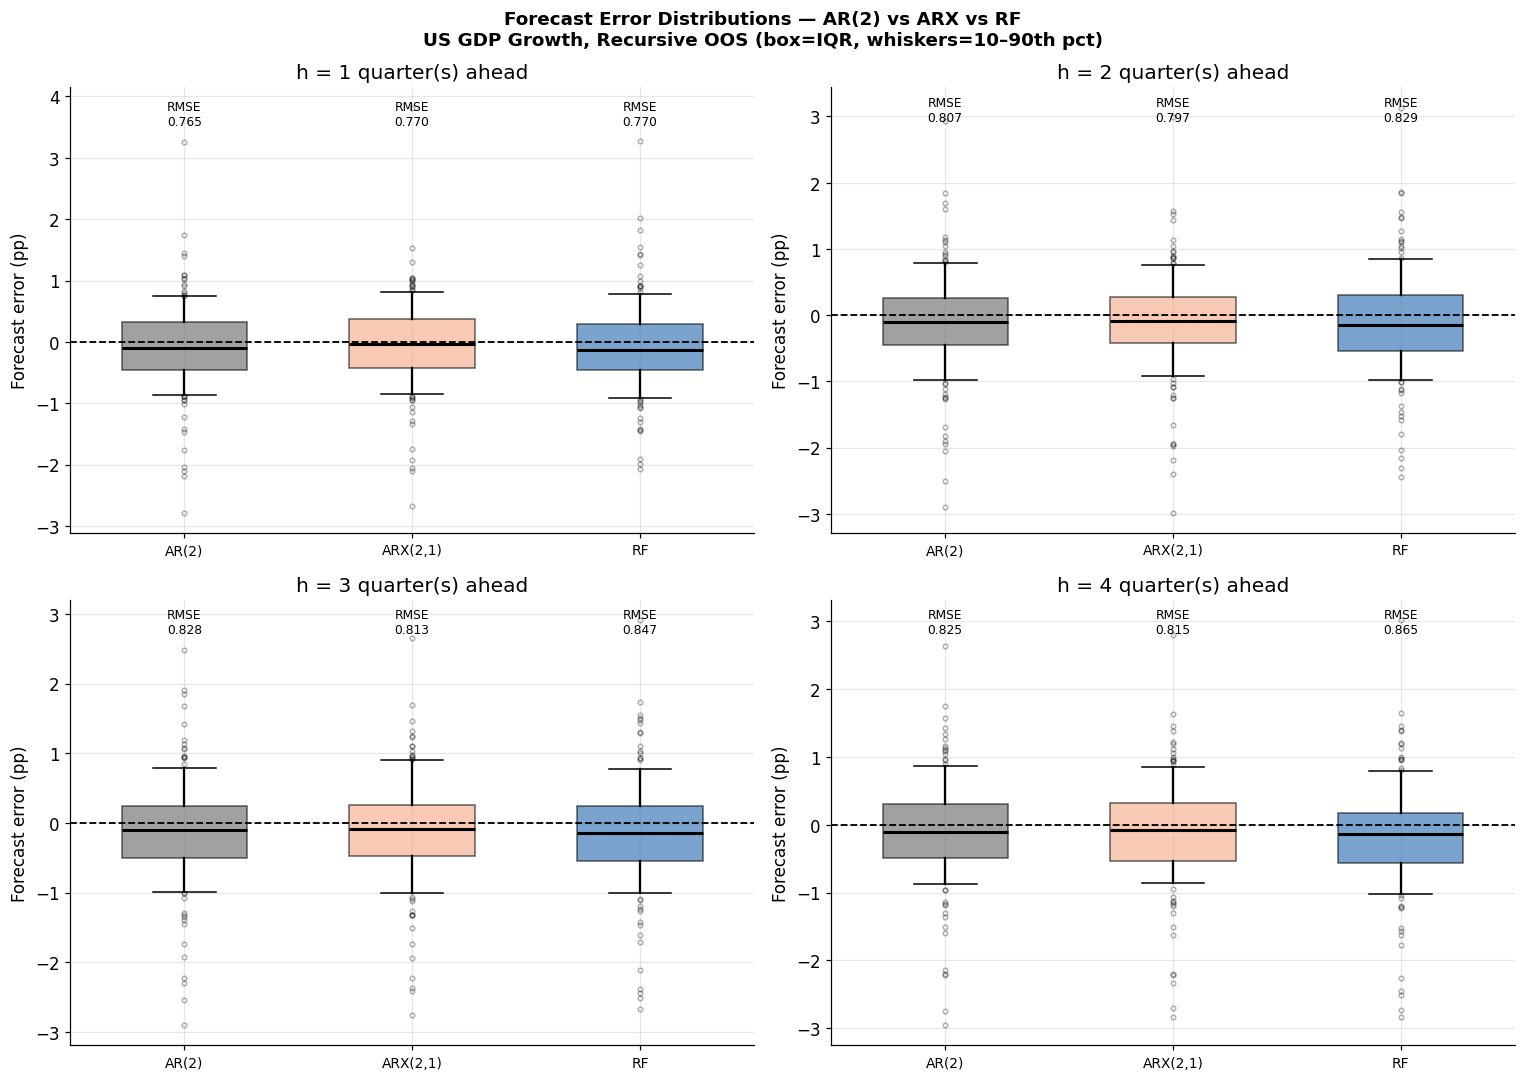

In [18]:
# ── Whisker plots: error distributions ───────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Forecast Error Distributions — AR(2) vs ARX vs RF\n"
             "US GDP Growth, Recursive OOS (box=IQR, whiskers=10–90th pct)",
             fontsize=12, fontweight='bold')

color_map = {'ar': GREY, 'arx': ORANGE, 'rf': BLUE}

for ax_idx, h in enumerate([1, 2, 3, 4]):
    ax = axes[ax_idx // 2, ax_idx % 2]
    data = [res[h][k] for _, k in models_list]

    bp = ax.boxplot(data, positions=[1, 2, 3], widths=0.55, patch_artist=True,
                    medianprops=dict(color='black', lw=2),
                    whiskerprops=dict(lw=1.5),
                    flierprops=dict(marker='o', ms=3, alpha=0.3),
                    whis=[10, 90])

    for patch, (_, key) in zip(bp['boxes'], models_list):
        patch.set_facecolor(color_map[key])
        patch.set_alpha(0.6)

    ax.axhline(0, color='black', lw=1.2, ls='--')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([l for l, _ in models_list], fontsize=9)
    ax.set_title(f"h = {h} quarter(s) ahead")
    ax.set_ylabel("Forecast error (pp)")

    for pos, (_, key) in enumerate([('AR(2)','ar'),('ARX','arx'),('RF','rf')], 1):
        ax.annotate(f"RMSE\n{rmse(res[h][key]):.3f}",
                    xy=(pos, ax.get_ylim()[1]*0.85),
                    ha='center', fontsize=8)

plt.tight_layout()
plt.show()

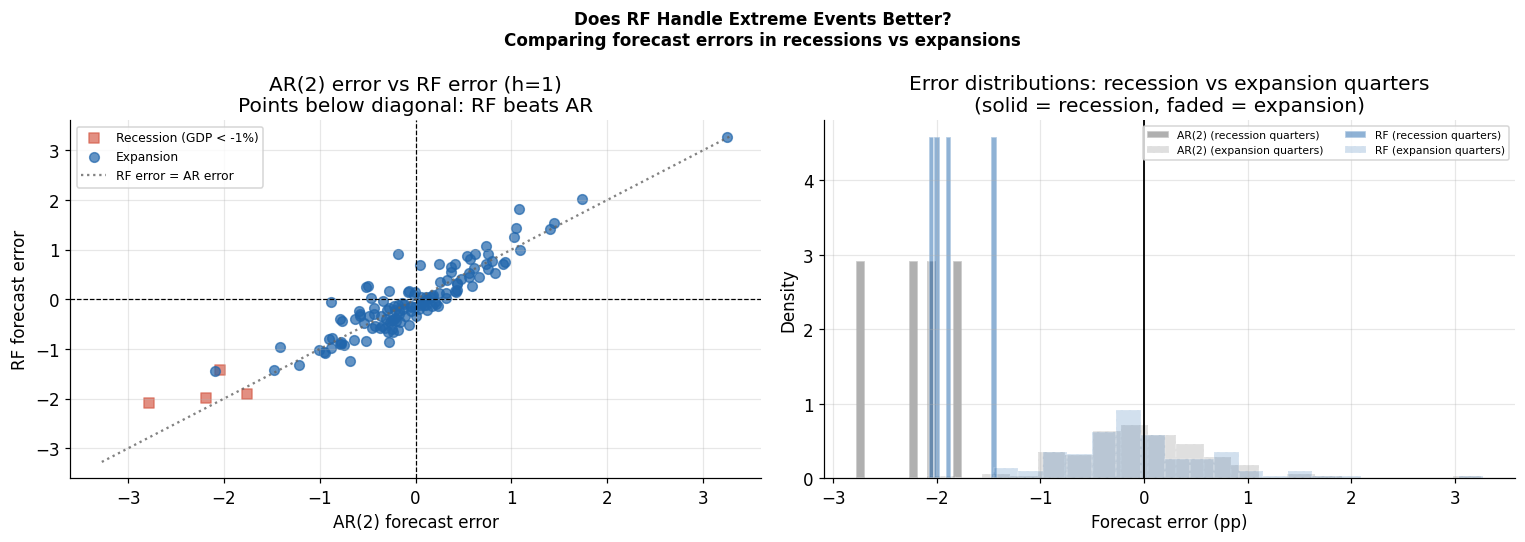

h=1 MAE during recession quarters (GDP < -1%):
  AR(2): 2.1901  |  RF: 1.8464  (RF better, n=4)

h=1 MAE during expansion quarters:
  AR(2): 0.4938  |  RF: 0.5254  (AR better, n=130)


In [19]:
# ── Non-linearity check: RF vs AR errors around recessions ───────────────────
#    Key question: does RF handle extreme events better than AR?

import matplotlib.patches as mpatches

h = 1
n_oos = len(res[h]['ar'])

# Reconstruct actual OOS values
oos_actuals = y_macro[min_train + h: min_train + h + n_oos]
oos_periods = df_macro.index[min_train + h: min_train + h + n_oos]

# Identify recession quarters in OOS period (GDP growth < -1%)
recession_mask = oos_actuals < -1.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Does RF Handle Extreme Events Better?\n"
             "Comparing forecast errors in recessions vs expansions",
             fontsize=11, fontweight='bold')

# Error scatter: recession vs non-recession
ax = axes[0]
for mask, label, color, marker in [
    (recession_mask,  'Recession (GDP < -1%)', RED,  's'),
    (~recession_mask, 'Expansion', BLUE, 'o'),
]:
    ax.scatter(np.array(res[h]['ar'])[mask],
               np.array(res[h]['rf'])[mask],
               s=40, color=color, alpha=0.7, marker=marker, label=label)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(0, color='black', lw=0.8, ls='--')
# 45-degree line
lim = max(abs(min(res[h]['ar'] + res[h]['rf'])),
          abs(max(res[h]['ar'] + res[h]['rf'])))
ax.plot([-lim, lim], [-lim, lim], color=GREY, lw=1.5, ls=':', alpha=0.8,
        label='RF error = AR error')
ax.set_xlabel("AR(2) forecast error")
ax.set_ylabel("RF forecast error")
ax.set_title("AR(2) error vs RF error (h=1)\nPoints below diagonal: RF beats AR")
ax.legend(fontsize=8)

# Error distributions: recession quarters only
ax2 = axes[1]
for key, label, color in [('ar', 'AR(2)', GREY), ('rf', 'RF', BLUE)]:
    e_all = np.array(res[h][key])
    ax2.hist(e_all[recession_mask], bins=12, color=color, alpha=0.5,
             edgecolor='white', density=True, label=f'{label} (recession quarters)')
    ax2.hist(e_all[~recession_mask], bins=20, color=color, alpha=0.2,
             edgecolor='white', density=True, ls='--',
             label=f'{label} (expansion quarters)')

ax2.axvline(0, color='black', lw=1.2)
ax2.set_xlabel("Forecast error (pp)")
ax2.set_ylabel("Density")
ax2.set_title("Error distributions: recession vs expansion quarters\n"
              "(solid = recession, faded = expansion)")
ax2.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

# Summary statistics
e_ar_rec = np.abs(np.array(res[h]['ar'])[recession_mask])
e_rf_rec = np.abs(np.array(res[h]['rf'])[recession_mask])
e_ar_exp = np.abs(np.array(res[h]['ar'])[~recession_mask])
e_rf_exp = np.abs(np.array(res[h]['rf'])[~recession_mask])

print(f"h=1 MAE during recession quarters (GDP < -1%):")
print(f"  AR(2): {e_ar_rec.mean():.4f}  |  RF: {e_rf_rec.mean():.4f}  "
      f"({'RF better' if e_rf_rec.mean() < e_ar_rec.mean() else 'AR better'}, "
      f"n={recession_mask.sum()})")
print(f"\nh=1 MAE during expansion quarters:")
print(f"  AR(2): {e_ar_exp.mean():.4f}  |  RF: {e_rf_exp.mean():.4f}  "
      f"({'RF better' if e_rf_exp.mean() < e_ar_exp.mean() else 'AR better'}, "
      f"n={(~recession_mask).sum()})")

---
## Summary — Random Forest Checklist and Key Takeaways

### The RF pipeline for time-series forecasting

| Step | Action | Key tool/formula |
|------|--------|-----------------|
| 1 | Understand tree splits | Greedy MSE minimisation at each node |
| 2 | Recognise overfitting risk | In-sample vs OOS RMSE by depth |
| 3 | Apply bagging | $\hat{y}^{\text{bag}} = \frac{1}{B}\sum T_b(x)$ |
| 4 | Decorrelate with random features | $m = \lfloor\sqrt{k}\rfloor$ features per split |
| 5 | Build lag feature matrix | Same lags as AR/ARX — no new concepts |
| 6 | Enforce temporal discipline | `TimeSeriesSplit` — **never** random CV |
| 7 | Tune `min_samples_leaf` | Grid search with TS cross-validation |
| 8 | Interpret | Permutation importance, PDP, SHAP |
| 9 | Evaluate honestly | Recursive RMSE/MAE vs AR and ARX benchmarks |

### The four-model story: AR → ARX → Bridge → RF

| Method | Added value over AR | Limitation |
|--------|--------------------|-|
| **AR(p)** | Baseline | Only own lags |
| **ARX(p,q)** | Economic relationships ($\Delta$unemp) | Linearity, needs quarterly $Z$ |
| **Bridge (M3)** | Within-quarter monthly timeliness | Complex two-stage, monthly data required |
| **RF (M4)** | Non-linearity, interactions | Needs larger samples, harder to interpret |

### When RF helps vs. when it doesn't

| RF tends to WIN | RF tends to LOSE |
|----------------|-----------------|
| Large sample (T > 500) | Small sample (T < 150) |
| Many correlated predictors | Few strong predictors |
| Non-linear regimes (recessions) | Near-linear relationships |
| High signal-to-noise ratio | Financial returns (near random walk) |

### The honest bottom line
With 140–200 quarterly observations and 24 features, the RF often **ties or slightly loses** to AR(2) in overall RMSE. This is **a real finding**, not a failure: it tells you the macro relationships in this period are approximately linear. The RF provides an important robustness check — and may outperform in specific regimes (deep recessions) or with more data.

---
*Complete: all four forecasting modules covered.*
*Modules 1–4 together implement the full seminar empirical requirements.*
